<a href="https://colab.research.google.com/github/atmajaprasad/Telecom-Churn-Analysis/blob/main/Telecom_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
pip install pandas

In [40]:
pip install matplotlib

In [41]:
pip install seaborn

In [42]:
pip install numpy

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df=pd.read_csv('Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [44]:
df.info()
#Gives the information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [45]:
#replacing the total charges as zero as the tenure is zero. As well as changing
#the datatype of the total charges
df["TotalCharges"]=df.TotalCharges.replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype("float")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [46]:
#Checking for null values in the dataframe
df.isnull().sum().sum()

np.int64(0)

In [47]:
#df.describe is used to obtain discryptive analysis of the data
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [48]:
#df.duplicated is used to check for duplicates
df.duplicated().sum()

np.int64(0)

In [49]:
#whenever there is a unique value check for duplicates
df["customerID"].duplicated().sum()

np.int64(0)

In [50]:
#Covert 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [51]:
def conv(value):
  if value==1:
    return "Yes"
  else:
    return "No"

df['SeniorCitizen']=df['SeniorCitizen'].apply(conv)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


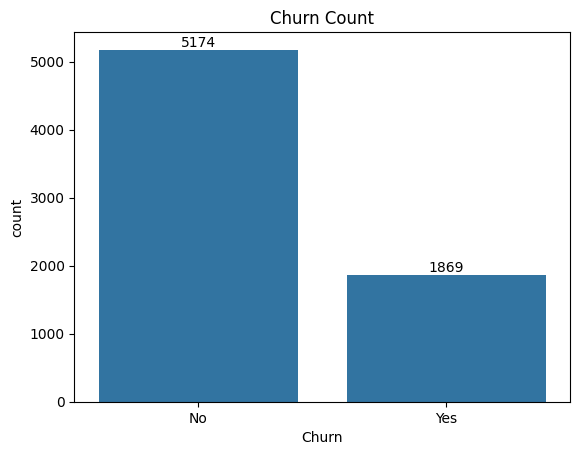

In [52]:
ax=sns.countplot(x=df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Churn Count")
plt.show()

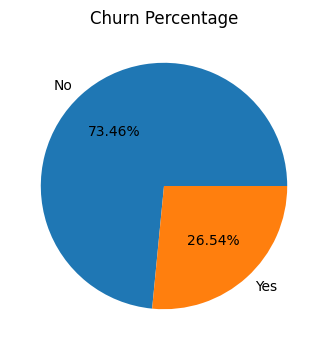

In [53]:
plt.figure(figsize=(4,4))
gb=df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'],labels=gb.index,autopct='%1.2f%%')
plt.title("Churn Percentage")
plt.show()

In [54]:
#From the given pie chart , 26.54% customer has churned out
# Next step is to figure out why the customer has churned out

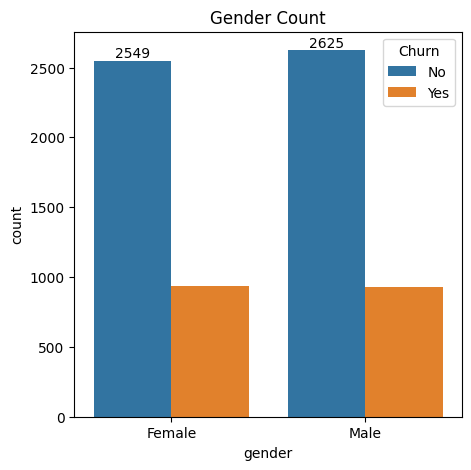

In [55]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x=df['gender'],hue=df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Gender Count")
plt.show()

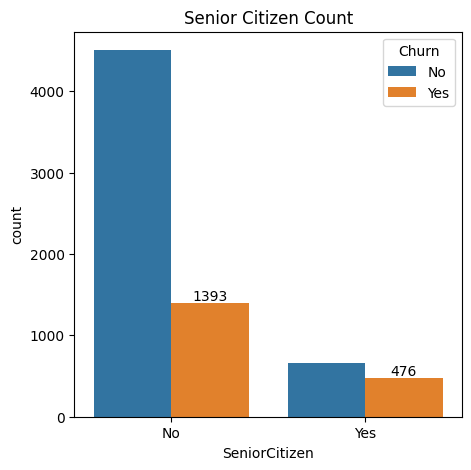

In [56]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x=df['SeniorCitizen'],hue=df['Churn'])
ax.bar_label(ax.containers[1])
plt.title("Senior Citizen Count")
plt.show()

In [57]:
#Comparitively a greater percentage of people in senior citizen category haev churned .

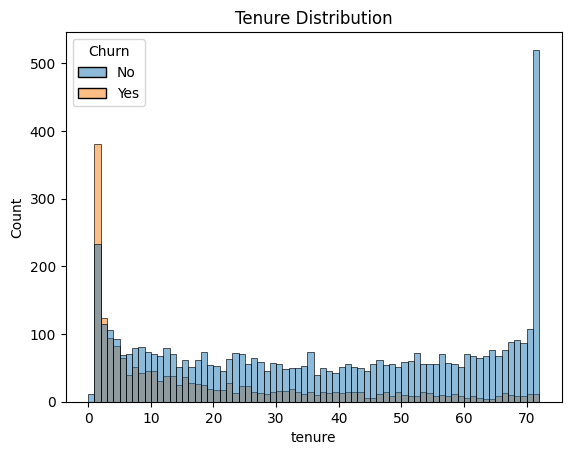

In [58]:

sns.histplot(x=df["tenure"],bins=72, hue=df["Churn"])
plt.title("Tenure Distribution")
plt.show()

People have churned out at the initial tenure period have churned and people who have stayed for the longer tenure period have not churned.

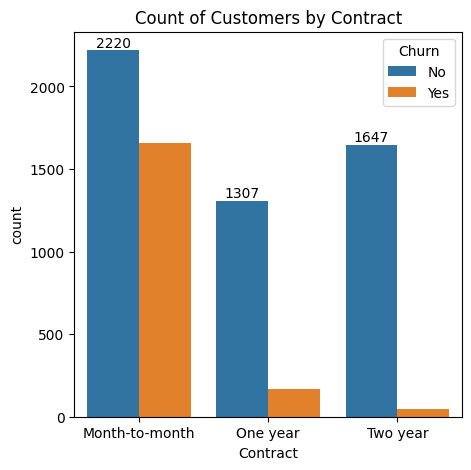

In [59]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x=df['Contract'],hue=df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

People have churned are the people who opt for the month to month contract . On the other hand people have been in a One year contract or a two year contract have very less likelihood of churning .Hence we can conclude by saying , people who are in a month-to-month contract are likely to churn , rather than the people who are in a much longer contract.

In [60]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

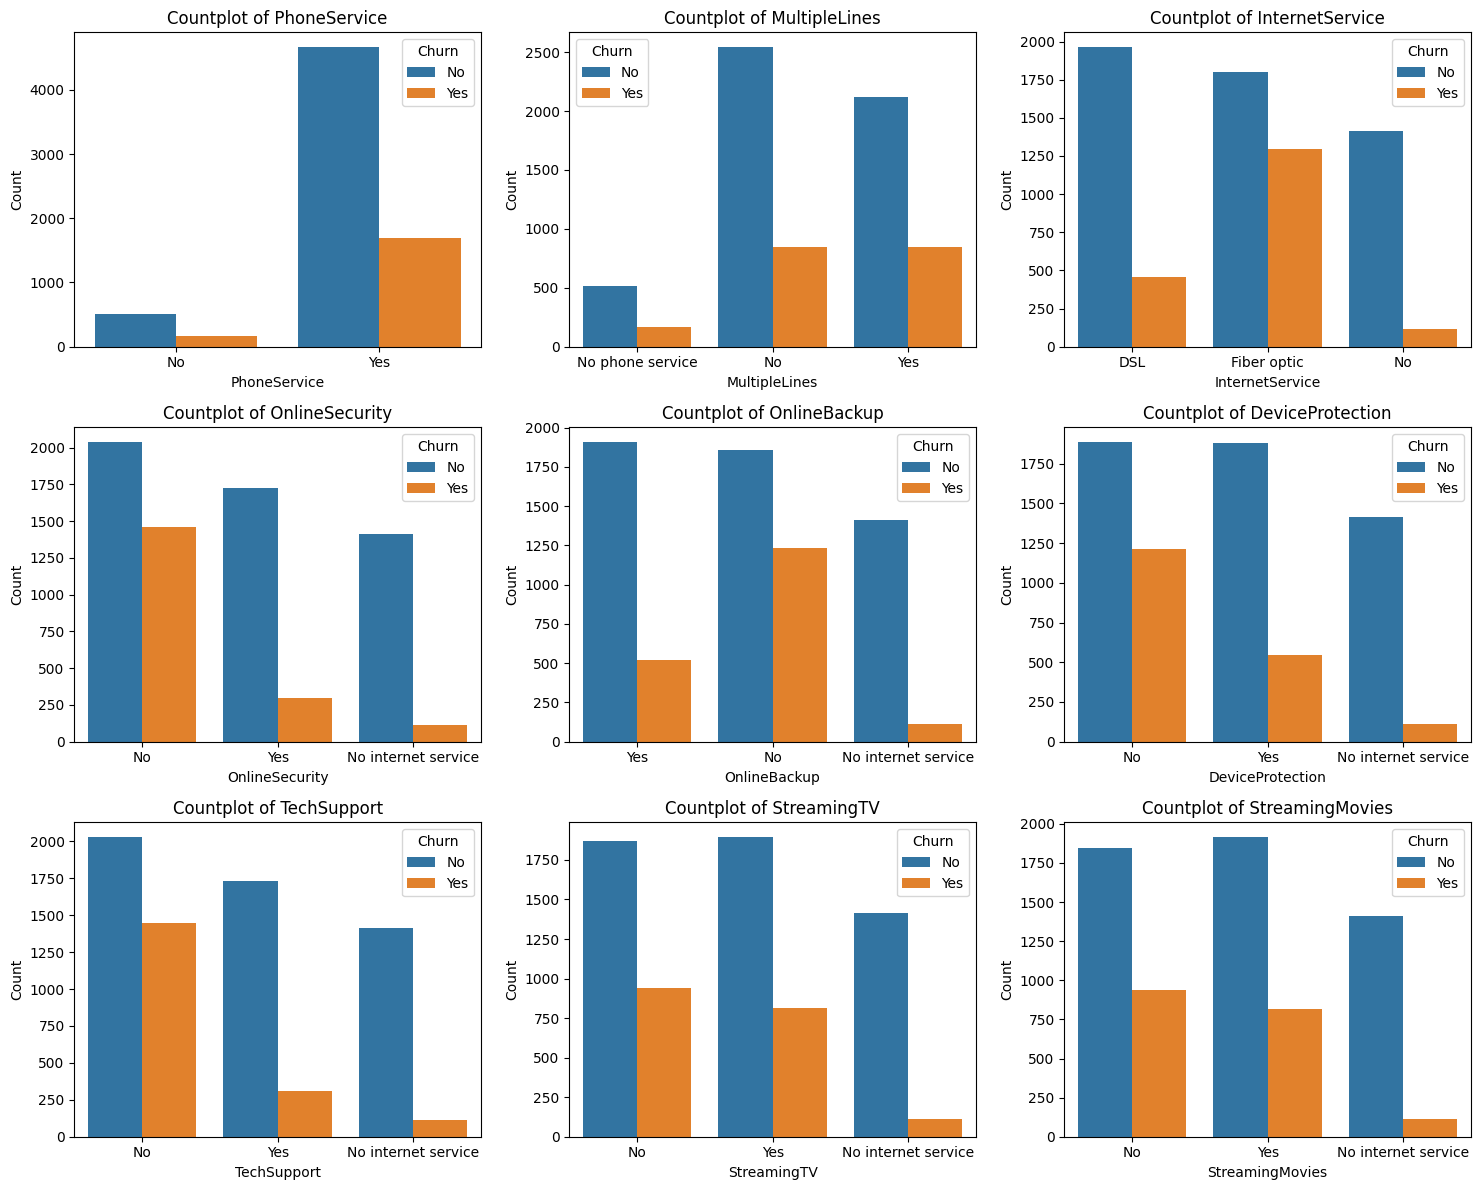

In [61]:
columns = ['PhoneService', 'MultipleLines', 'InternetService',
           'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
           'TechSupport', 'StreamingTV', 'StreamingMovies']

# Define the size of the figure and number of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over the columns and plot countplots
for i, col in enumerate(columns):
    sns.countplot(data=df, x=col, ax=axes[i],hue=df['Churn'])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

Customers without these services (indicated by "No") appear to churn at higher rates than those with them. For some services, such as Online Security and Tech Support, the absence of these services correlates with a noticeable increase in churn.

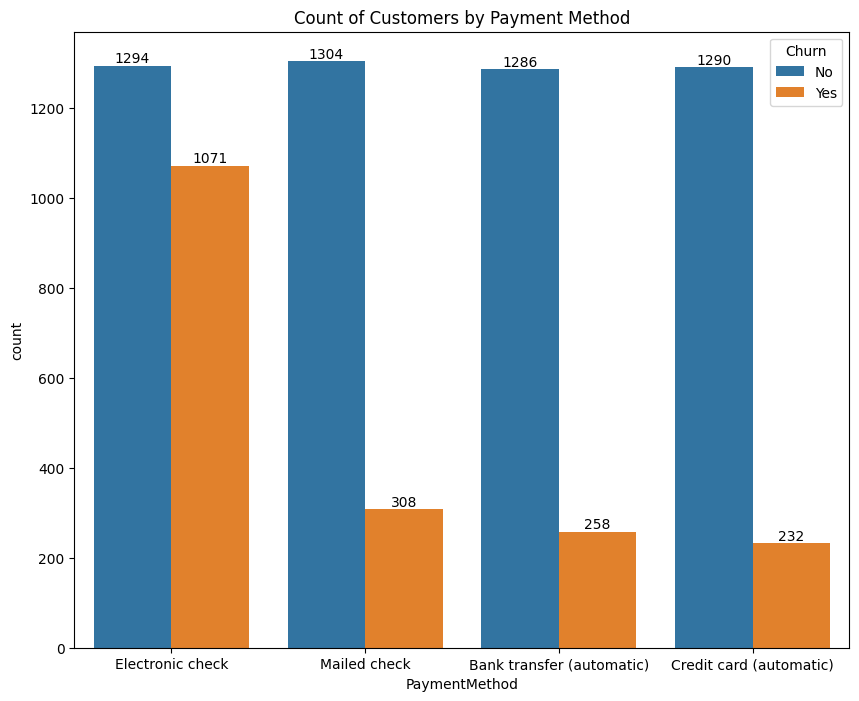

In [62]:
plt.figure(figsize=(10,8))
ax=sns.countplot(x=df['PaymentMethod'],hue=df['Churn'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers by Payment Method")
plt.show()

Customers are likely to churn when they are using Electronic Check as their payment method

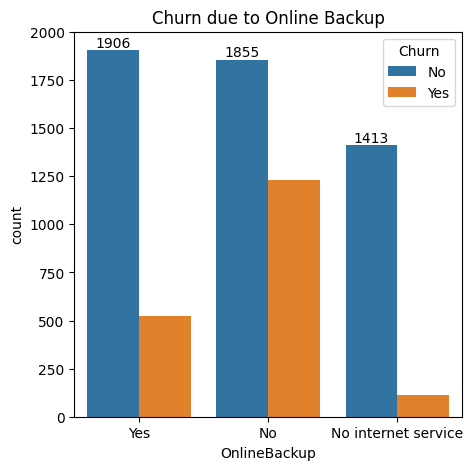

In [63]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x=df['OnlineBackup'],hue=df['Churn'])
ax.bar_label(ax.containers[0])
plt.title("Churn due to Online Backup")
plt.show()

Product & Business Metrics

In [64]:
churn_rate = df['Churn'].value_counts(normalize=True)['Yes']

In [65]:
#Average Reavnue Per User
arpu = df['MonthlyCharges'].mean()

In [66]:
#Customer Lifetime Value
df['CLV'] = df['MonthlyCharges'] * df['tenure']

In [67]:
#Tenure
df['Tenure'] = df['tenure']

In [68]:
#CHURN BY CONTRACT TYPE

contract_analysis = (
    df.groupby('Contract')
      .agg(
          Total_Customers=('customerID', 'count'),
          Churned_Customers=('Churn', lambda x: (x == 'Yes').sum()),
          Avg_Revenue=('MonthlyCharges', 'mean')
      )
)

# Churn rate per contract
contract_analysis['Churn_Rate'] = (
    contract_analysis['Churned_Customers'] /
    contract_analysis['Total_Customers']
)

# Revenue at risk due to churn
contract_analysis['Revenue_At_Risk'] = (
    contract_analysis['Total_Customers'] *
    contract_analysis['Churn_Rate'] *
    contract_analysis['Avg_Revenue']
)

contract_analysis = contract_analysis.sort_values(
    'Revenue_At_Risk', ascending=False
)

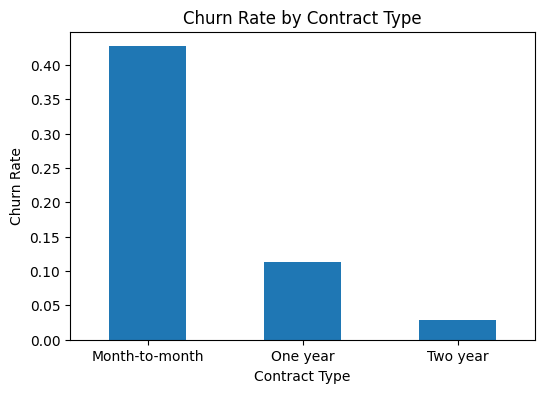

In [69]:
contract_analysis['Churn_Rate'].plot(
    kind='bar',
    figsize=(6,4)
)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.show()


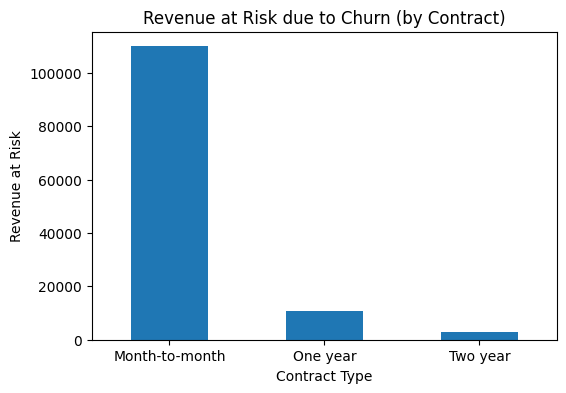

In [70]:
contract_analysis['Revenue_At_Risk'].plot(
    kind='bar',
    figsize=(6,4)
)
plt.title('Revenue at Risk due to Churn (by Contract)')
plt.ylabel('Revenue at Risk')
plt.xlabel('Contract Type')
plt.xticks(rotation=0)
plt.show()


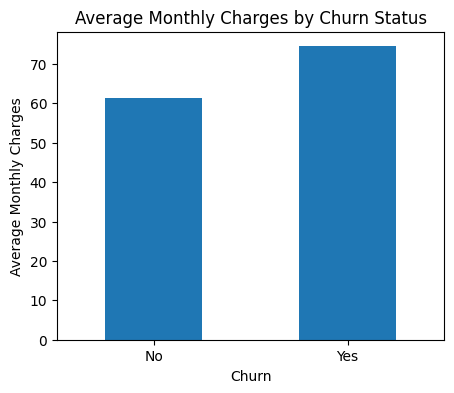

In [71]:
price_churn = (
    df.groupby('Churn')['MonthlyCharges']
      .mean()
      .reset_index()
)

price_churn.plot(
    x='Churn',
    y='MonthlyCharges',
    kind='bar',
    figsize=(5,4),
    legend=False
)
plt.title('Average Monthly Charges by Churn Status')
plt.ylabel('Average Monthly Charges')
plt.xlabel('Churn')
plt.xticks(rotation=0)
plt.show()


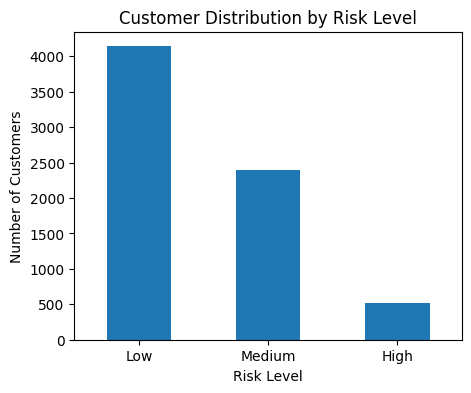

In [72]:
df['Risk_Score'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 2 +
    (df['tenure'] < 6).astype(int) * 2 +
    (df['MonthlyCharges'] > 70).astype(int)
)

df['Risk_Level'] = pd.cut(
    df['Risk_Score'],
    bins=[-1, 2, 4, 6],
    labels=['Low', 'Medium', 'High']
)
df['Risk_Level'].value_counts().plot(
    kind='bar',
    figsize=(5,4)
)
plt.title('Customer Distribution by Risk Level')
plt.ylabel('Number of Customers')
plt.xlabel('Risk Level')
plt.xticks(rotation=0)
plt.show()


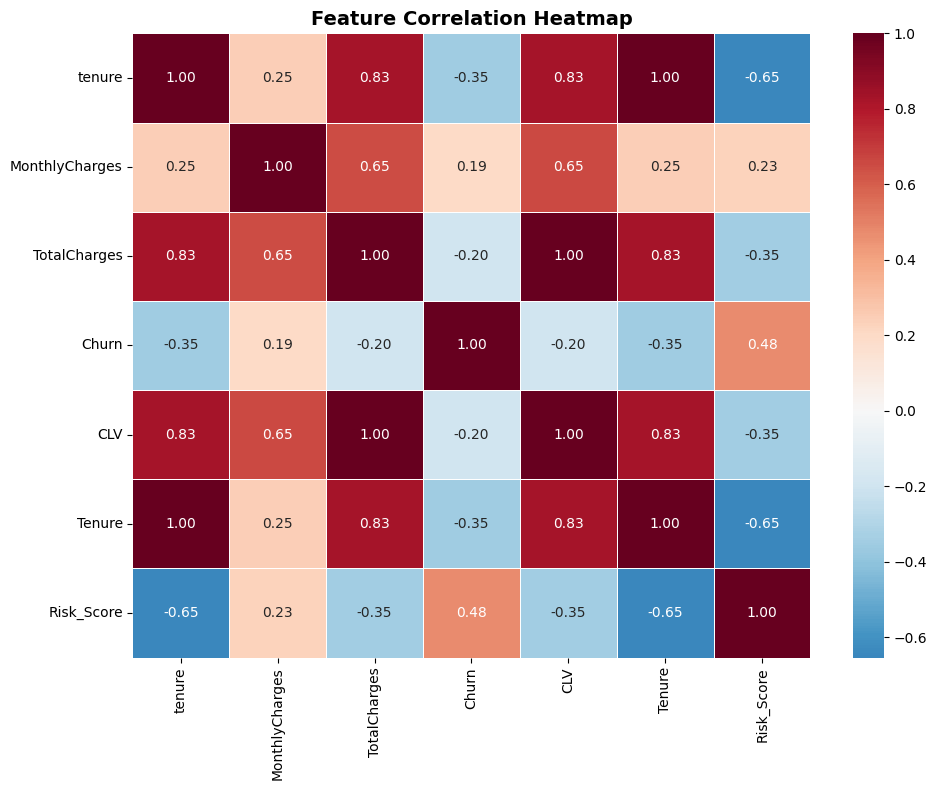

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

df_enc = df.copy()
df_enc['Churn'] = (df_enc['Churn'] == 'Yes').astype(int)
num_cols = df_enc.select_dtypes(include='number').columns

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_enc[num_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [76]:
from scipy.stats import chi2_contingency
import pandas as pd


ct = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, expected = chi2_contingency(ct)

print("CHI-SQUARE TEST: Contract Type vs Churn")
print(f"Chi2 statistic : {chi2:.2f}")
print(f"P-value        : {p:.6f}")
print(f"Degrees of freedom: {dof}")
print()
if p < 0.05:
    print("SIGNIFICANT — Contract type IS a significant driver of churn.")
else:
    print("Not significant at 0.05 level.")

churn_by_contract = (df.groupby('Contract')['Churn']
                       .apply(lambda x: (x == 'Yes').mean() * 100)
                       .round(1))
print("\nChurn rate by contract type:")
print(churn_by_contract)

mtm = churn_by_contract.get('Month-to-month', None)
other = churn_by_contract[churn_by_contract.index != 'Month-to-month'].mean()
if mtm:
    diff = mtm - other
    print(f"\nMonth-to-month churn: {mtm}%  vs  others avg: {other:.1f}%")
    print(f"month-to-month customers showed {diff:.0f}% higher attrition risk")

CHI-SQUARE TEST: Contract Type vs Churn
Chi2 statistic : 1184.60
P-value        : 0.000000
Degrees of freedom: 2

SIGNIFICANT — Contract type IS a significant driver of churn.

Churn rate by contract type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

Month-to-month churn: 42.7%  vs  others avg: 7.1%
month-to-month customers showed 36% higher attrition risk


LOGISTIC REGRESSION RESULTS
Accuracy : 80.2%
F1 Score : 59.9%

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

 (accuracy: 80%, F1: 60%)


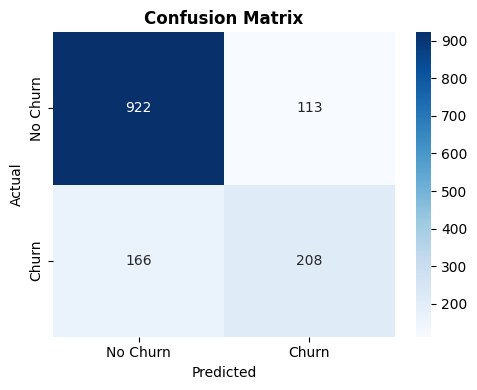

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_model = df.copy()


df_model = df_model.drop('customerID', axis=1)

le = LabelEncoder()


cat_cols = df_model.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    if col != 'Churn':
        df_model[col] = le.fit_transform(df_model[col].astype(str))


df_model['Churn'] = le.fit_transform(df_model['Churn'].astype(str))

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred) * 100
f1     = f1_score(y_test, y_pred) * 100

print("LOGISTIC REGRESSION RESULTS")
print(f"Accuracy : {acc:.1f}%")
print(f"F1 Score : {f1:.1f}%")
print()
print(classification_report(y_test, y_pred,
      target_names=['No Churn', 'Churn']))
print(f" (accuracy: {acc:.0f}%, F1: {f1:.0f}%)")


cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'], ax=ax)
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()